In [ ]:
!pip install torch torchvision albumentations pillow transformers datasets timm segmentation-models-pytorch tqdm timm

## Drive Connection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data extraction

In [ ]:
path = "/content/drive/MyDrive/SegNetX(solar panels)/Dataset/PV08.zip"

In [ ]:
import subprocess
subprocess.run(["7z", "x", path, "-ooutput_folder"])

CompletedProcess(args=['7z', 'x', '/content/drive/MyDrive/SegNetX(solar panels)/Dataset/PV08.zip', '-ooutput_folder'], returncode=2)

In [ ]:
dataset_path = "/content/output_folder/PV08"

In [ ]:
import os
import shutil
import random
image_dirs = [os.path.join(dataset_path,i) for i in os.listdir(dataset_path)]
image_dirs

['/content/output_folder/PV08/PV08_Ground',
 '/content/output_folder/PV08/PV08_Rooftop']

In [ ]:
# Define output folders
dataset_base = "/content/dataset"
splits = ["train", "val", "test"]
# Ensure output directories exist
for split in splits:
    os.makedirs(os.path.join(dataset_base, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_base, split, "labels"), exist_ok=True)

In [ ]:
# Train-Validation-Test split ratio
train_ratio = 0.7  # 70% training
val_ratio = 0.2    # 20% validation
test_ratio = 0.1   # 10% testing

In [ ]:
# Process each image directory
all_image_label_pairs = []  # Store (image, label) pairs
for img_dir in image_dirs:
    all_images = sorted([f for f in os.listdir(img_dir) if f.endswith('.bmp')])
    # Label directory should be the same as image dir but for labels
    label_dir = img_dir  # Assuming labels are stored in the same directory
    print(label_dir)
    all_labels = sorted([f for f in os.listdir(label_dir) if f.endswith('.bmp') and "_label" in f])
    # Ensure matching image-label pairs
    for img in all_images:
        label_name = img.replace(".bmp", "_label.bmp")  # Match label
        if label_name in all_labels:
            all_image_label_pairs.append((os.path.join(img_dir, img), os.path.join(label_dir, label_name)))

/content/output_folder/PV08/PV08_Ground
/content/output_folder/PV08/PV08_Rooftop


In [ ]:
# Shuffle data
random.shuffle(all_image_label_pairs)

# Split into train, val, and test
total = len(all_image_label_pairs)
train_idx = int(total * train_ratio)
val_idx = train_idx + int(total * val_ratio)

train_set = all_image_label_pairs[:train_idx]
val_set = all_image_label_pairs[train_idx:val_idx]
test_set = all_image_label_pairs[val_idx:]
# Function to move files
def move_files(data_set, subset):
    for img_path, label_path in data_set:
        shutil.copy(img_path, os.path.join(dataset_base, subset, "images", os.path.basename(img_path)))
        shutil.copy(label_path, os.path.join(dataset_base, subset, "labels", os.path.basename(label_path)))

# Move files to respective folders
move_files(train_set, "train")
move_files(val_set, "val")
move_files(test_set, "test")

print("Dataset split completed: Training, Validation, and Testing sets are ready!")

Dataset split completed: Training, Validation, and Testing sets are ready!


In [ ]:
import os

dataset_base = "/content/output_folder/PV08/PV08_Ground"

# List all files and directories
all_files = os.listdir(dataset_base)

# If you only want files (not folders), you can filter like this:
files = [f for f in all_files if os.path.isfile(os.path.join(dataset_base, f))]

# Print number of files
print("Dataset size:", len(files))

dataset_base = "/content/output_folder/PV08/PV08_Rooftop"

# List all files and directories
all_files = os.listdir(dataset_base)

# If you only want files (not folders), you can filter like this:
files = [f for f in all_files if os.path.isfile(os.path.join(dataset_base, f))]

# Print number of files
print("Dataset size:", len(files))

Dataset size: 1346
Dataset size: 180


## Modules

In [ ]:
import os
import torch
import torchvision.transforms as T
import numpy as np
from transformers import  AutoFeatureExtractor
from torch.utils.data import Dataset, DataLoader
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

import timm

from transformers import SegformerForSemanticSegmentation
from torch.cuda.amp import autocast, GradScaler

## Load dataset & Pre-processing

In [ ]:
# Define Image & Label Preprocessing
transform = A.Compose([
    A.Resize(256, 256),  # Resize images & labels
    A.HorizontalFlip(p=0.5),  # Random flip
    A.RandomBrightnessContrast(p=0.2),  # Random brightness
    A.Normalize(mean=(0.5,), std=(0.5,)),  # Normalize for UNet
    ToTensorV2()
])
class SolarPVDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.image_filenames = [f for f in sorted(os.listdir(image_dir)) if f.endswith('.bmp')]



    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
      img_name = self.image_filenames[idx]
      img_path = os.path.join(self.image_dir, img_name)
      label_path = os.path.join(self.label_dir, img_name.replace(".bmp", "_label.bmp"))
      print(f"Loading image: {img_path}")
      print(f"Loading mask: {label_path}")

      # Read image
      image = cv2.imread(img_path, cv2.IMREAD_COLOR)  # Default mode
      if image is None:
          raise FileNotFoundError(f"Image not found or unreadable: {img_path}")
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
      if mask is None:
          raise FileNotFoundError(f"Mask not found or unreadable: {label_path}")
      # Apply transformations
      if self.transform:
          transformed = self.transform(image=image, mask=mask)
          image, mask = transformed["image"], transformed["mask"]
          mask = mask.float()
          mask[mask > 0] = 1.0

      return image, mask


# Define dataset paths
train_dataset = SolarPVDataset("/content/dataset/train/images", "/content/dataset/train/labels", transform)
val_dataset = SolarPVDataset("/content/dataset/val/images", "/content/dataset/val/labels", transform)
test_dataset = SolarPVDataset("/content/dataset/test/images", "/content/dataset/test/labels", transform)

## Data Visualization

In [ ]:
train_dataset.__len__(),val_dataset.__len__(),test_dataset.__len__()

(690, 269, 151)

Loading image: /content/dataset/train/images/PV08_314139_1209745.bmp
Loading mask: /content/dataset/train/labels/PV08_314139_1209745_label.bmp


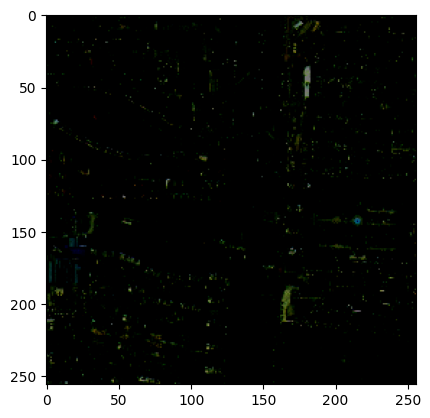

In [ ]:
img, mask = train_dataset.__getitem__(5)
image_np = img.permute(1,2,0).numpy()
plt.imshow(image_np,cmap='gray')

In [ ]:
mask.unique()

tensor([0., 1.])

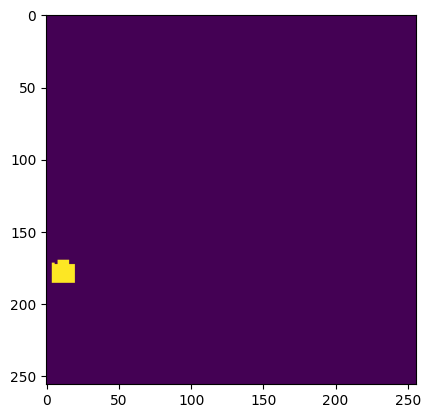

In [ ]:
plt.imshow(mask)

## DataLoader

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

## Enery calculation

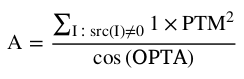

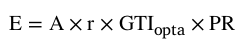

In [ ]:
img, mask = train_dataset.__getitem__(6)

Loading image: /content/dataset/train/images/PV08_314140_1209573.bmp
Loading mask: /content/dataset/train/labels/PV08_314140_1209573_label.bmp


In [ ]:
def compute_solar_area(mask, PTM=0.125, OPTA=34):
    """
    Compute solar panel area from a binary segmentation mask.

    Args:
        mask (torch.Tensor or np.ndarray): Binary mask (1 = panel, 0 = background)
        PTM (float): Pixel-to-Meter Ratio (default = 0.125 m² per pixel)
        OPTA (float): Optimum Tilt Angle (default = 34°)

    Returns:
        float: Estimated solar panel area (m²)
    """
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().detach().numpy()  # Convert to NumPy if Tensor
    if mask.ndim == 3:
        mask = mask.squeeze(0)  # Remove extra channel

    mask = (mask > 0.5).astype(np.float32)  # Ensure binary mask
    panel_pixels = mask.sum()  # Count solar panel pixels
    area_m2 = (panel_pixels * (PTM ** 2)) / np.cos(np.radians(OPTA))  # Convert to m²
    return area_m2

def compute_accuracy_metrics(segmented_mask, actual_mask, PTM=0.125):
    """
    Compute accuracy of segmented area vs. actual area using MAPE and IoU.

    Args:
        segmented_mask (torch.Tensor or np.ndarray): Predicted segmentation mask.
        actual_mask (torch.Tensor or np.ndarray): Ground truth segmentation mask.
        PTM (float): Pixel-to-Meter Ratio (default = 0.125 m² per pixel).

    Returns:
        dict: Dictionary containing MAPE error and IoU score.
    """
    # Compute solar panel areas
    segmented_area = compute_solar_area(segmented_mask, PTM)
    actual_area = compute_solar_area(actual_mask, PTM)

    # Compute Mean Absolute Percentage Error (MAPE)
    mape_error = np.abs((segmented_area - actual_area) / actual_area) * 100 if actual_area != 0 else 0

    # Compute Intersection over Union (IoU)
    intersection = ((segmented_mask > 0.5) & (actual_mask > 0.5)).sum()
    union = ((segmented_mask > 0.5) | (actual_mask > 0.5)).sum()
    iou_score = intersection / union if union != 0 else 0

    return {
        "Segmented Area (m²)": segmented_area,
        "Actual Area (m²)": actual_area,
        "MAPE (%)": mape_error,
        "IoU Score": iou_score
    }
compute_accuracy_metrics(mask,mask)

{'Segmented Area (m²)': np.float64(10.15861678505633),
 'Actual Area (m²)': np.float64(10.15861678505633),
 'MAPE (%)': np.float64(0.0),
 'IoU Score': tensor(1.)}

In [ ]:
area = compute_solar_area(mask)

In [ ]:
def compute_energy_output(area_m2, efficiency=0.19, GTI=1676.2, PR=0.935):
    """
    Compute estimated solar energy output.

    Args:
        area_m2 (float): Solar panel area in m²
        efficiency (float): Solar panel efficiency (default = 19%)
        GTI (float): Global Tilted Irradiation in kWh/m² (default = 1676.2 kWh/m²)
        PR (float): Performance Ratio (default = 93.5%)

    Returns:
        float: Estimated energy output (kWh per year)
    """
    return area_m2 * efficiency * GTI * PR

3025.001719300544
Estimated Solar Panel Area: 10.16 m²
Estimated Energy Output: 3025.00 kWh per year


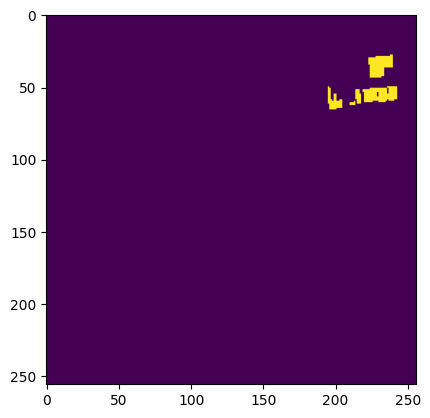

In [ ]:
print(compute_energy_output(area))
# Compute area in m²
area_m2 = compute_solar_area(mask)
print(f"Estimated Solar Panel Area: {area_m2:.2f} m²")

# Compute energy output in kWh
energy_kwh = compute_energy_output(area_m2)
print(f"Estimated Energy Output: {energy_kwh:.2f} kWh per year")
plt.imshow(mask)

# Built Model

## Segformer + Unet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerForSemanticSegmentation

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose([
    A.Resize(256, 256),  # Resize to SegFormer input size
    A.HorizontalFlip(p=0.5),  # Randomly flip horizontally
    A.VerticalFlip(p=0.2),  # Randomly flip vertically
    A.RandomBrightnessContrast(p=0.2),  # Adjust brightness and contrast
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=20, p=0.5),  # Small shifts, scaling, rotation
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),  # Slight blurring for robustness
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),  # Add slight Gaussian noise
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.2),  # Slight grid distortion
    A.Normalize(mean=[0.5], std=[0.5]),  # Normalize
    ToTensorV2()  # Convert to tensor
])

# Custom Dataset Class
class SolarPanelDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx].replace(".bmp", "_label.bmp"))

        # Load Image & Mask
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype("uint8")  # Convert to binary mask
        # Apply Transformations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.unsqueeze(0)  # Add channel dimension

# Load Dataset
train_dataset = SolarPanelDataset("/content/dataset/train/images", "/content/dataset/train/labels", transform=transform)
val_dataset = SolarPanelDataset("/content/dataset/val/images", "/content/dataset/val/labels", transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Dataset Loaded: {len(train_dataset)} train, {len(val_dataset)} val samples")

Dataset Loaded: 690 train, 269 val samples


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_12708/4161820326.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),  # Add slight Gaussian noise


In [ ]:
import torch
import torch.nn as nn
from transformers import SegformerForSemanticSegmentation

class SegFormerUNet(nn.Module):
    def __init__(self, model_name="nvidia/segformer-b2-finetuned-ade-512-512", num_classes=1):
        super(SegFormerUNet, self).__init__()

        # Load Pretrained SegFormer
        self.segformer = SegformerForSemanticSegmentation.from_pretrained(model_name)

        # Extract Encoder
        self.encoder = self.segformer.segformer.encoder  # Correct way to get encoder

        # U-Net Style Decoder (Upsampling to match input size)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),  # 16x16 -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),  # 32x32 -> 64x64
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),   # 64x64 -> 128x128
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),    # 128x128 -> 256x256
            nn.ReLU(),
            nn.ConvTranspose2d(32, num_classes, kernel_size=2, stride=2)  # 256x256 -> 512x512
        )

    def forward(self, x):
        retained_input = x  # Keep input image

        # Encoder processing
        encoder_output = self.encoder(x)  # Extract encoder features
        encoder_output = encoder_output.last_hidden_state.permute(0, 1, 2, 3)  # (B, C, H, W)
        # print("Encoder Output Shape:", encoder_output.shape)  # Should be (B, 512, 16, 16)

        # Decoder (Upsample back to input size)
        output = self.decoder(encoder_output)  # (B, num_classes, 512, 512)

        return output  # Retain input & return segmentation mask

# Test Model with Random Input
sample_input = torch.randn(1, 3, 512, 512).cuda()
model = SegFormerUNet().cuda()
model.eval()

with torch.no_grad():
    output = model(sample_input)

print("Output Shape:", output.shape)  # (1, 1, 512, 512) Now matches input size

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Output Shape: torch.Size([1, 1, 512, 512])


In [ ]:
def dice_score(preds, targets):
    smooth = 1e-6
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    return (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)

def iou_score(preds, targets):
    smooth = 1e-6
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return (intersection + smooth) / (union + smooth)

def pixel_accuracy(preds, targets):
    preds = (preds > 0.5).float()
    return (preds == targets).float().mean()

In [ ]:
# Loss Function: BCE + Dice Loss
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1):
        super(DiceBCELoss, self).__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)

        preds = torch.sigmoid(preds)
        intersection = (preds * targets).sum(dim=(2, 3))
        dice_loss = 1 - ((2. * intersection + self.smooth) / (preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + self.smooth)).mean()

        return 0.5 * bce_loss + 0.5 * dice_loss

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
        pt = torch.exp(-BCE)
        F_loss = (1 - pt) ** self.gamma * BCE
        return F_loss.mean()

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

/tmp/ipykernel_12708/4064525168.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # Enable Mixed Precision
/tmp/ipykernel_12708/4064525168.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/200:   0%|          | 0/87 [00:00<?, ?it/s]/tmp/ipykernel_12708/4064525168.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_12708/4064525168.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/200] | Train Loss: 0.5897 | Val Loss: 0.4416 | Dice: 0.0000 | IoU: 0.0000 | Acc: 0.8825


Epoch [2/200] | Train Loss: 0.3785 | Val Loss: 0.3035 | Dice: 0.7028 | IoU: 0.5493 | Acc: 0.9357


Epoch [3/200] | Train Loss: 0.3079 | Val Loss: 0.2853 | Dice: 0.7497 | IoU: 0.6071 | Acc: 0.9387


...

Epoch [5/200] | Train Loss: 0.2658 | Val Loss: 0.2361 | Dice: 0.7879 | IoU: 0.6578 | Acc: 0.9486


Epoch [6/200] | Train Loss: 0.2467 | Val Loss: 0.2188 | Dice: 0.8084 | IoU: 0.6882 | Acc: 0.9551


Epoch [7/200] | Train Loss: 0.2358 | Val Loss: 0.2116 | Dice: 0.7948 | IoU: 0.6696 | Acc: 0.9531


Epoch [8/200] | Train Loss: 0.2340 | Val Loss: 0.2064 | Dice: 0.8129 | IoU: 0.6931 | Acc: 0.9587


Epoch [9/200] | Train Loss: 0.2207 | Val Loss: 0.2009 | Dice: 0.8035 | IoU: 0.6812 | Acc: 0.9585


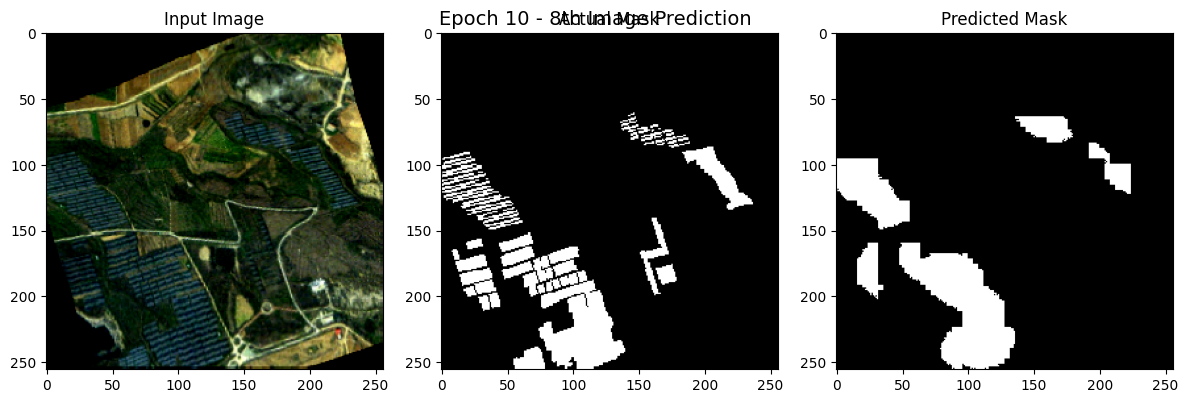

Epoch [10/200] | Train Loss: 0.2167 | Val Loss: 0.1952 | Dice: 0.8064 | IoU: 0.6847 | Acc: 0.9593


Epoch [11/200] | Train Loss: 0.2100 | Val Loss: 0.1924 | Dice: 0.8183 | IoU: 0.7015 | Acc: 0.9604


Epoch [12/200] | Train Loss: 0.2041 | Val Loss: 0.1786 | Dice: 0.8218 | IoU: 0.7048 | Acc: 0.9624


Epoch [13/200] | Train Loss: 0.2020 | Val Loss: 0.1948 | Dice: 0.8125 | IoU: 0.6941 | Acc: 0.9603


Epoch [14/200] | Train Loss: 0.2119 | Val Loss: 0.1852 | Dice: 0.8325 | IoU: 0.7202 | Acc: 0.9630


Epoch [15/200] | Train Loss: 0.1992 | Val Loss: 0.1816 | Dice: 0.8273 | IoU: 0.7140 | Acc: 0.9636


Epoch [16/200] | Train Loss: 0.1915 | Val Loss: 0.1807 | Dice: 0.8313 | IoU: 0.7182 | Acc: 0.9605


Epoch [17/200] | Train Loss: 0.2139 | Val Loss: 0.1899 | Dice: 0.8259 | IoU: 0.7100 | Acc: 0.9595


Epoch [18/200] | Train Loss: 0.2040 | Val Loss: 0.1946 | Dice: 0.8249 | IoU: 0.7114 | Acc: 0.9637


Epoch [19/200] | Train Loss: 0.2168 | Val Loss: 0.1762 | Dice: 0.8432 | IoU: 0.7360 | Acc: 0.9637


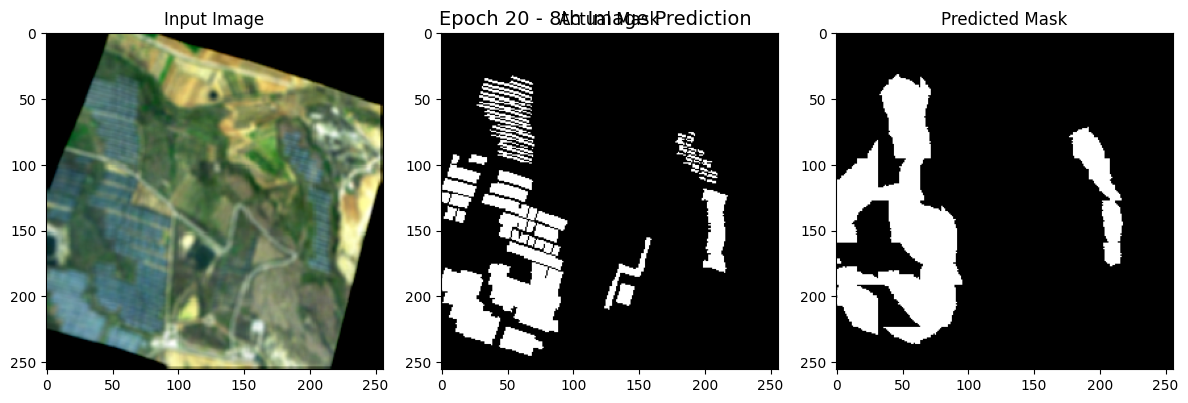

Epoch [20/200] | Train Loss: 0.1928 | Val Loss: 0.1864 | Dice: 0.8288 | IoU: 0.7184 | Acc: 0.9616


Epoch [21/200] | Train Loss: 0.1937 | Val Loss: 0.1827 | Dice: 0.8337 | IoU: 0.7243 | Acc: 0.9628


Epoch [22/200] | Train Loss: 0.1797 | Val Loss: 0.1643 | Dice: 0.8511 | IoU: 0.7472 | Acc: 0.9657


Epoch [23/200] | Train Loss: 0.1820 | Val Loss: 0.1815 | Dice: 0.8321 | IoU: 0.7206 | Acc: 0.9616


Epoch [24/200] | Train Loss: 0.1795 | Val Loss: 0.1682 | Dice: 0.8419 | IoU: 0.7334 | Acc: 0.9649


Epoch [25/200] | Train Loss: 0.1744 | Val Loss: 0.1683 | Dice: 0.8480 | IoU: 0.7433 | Acc: 0.9666


Epoch [26/200] | Train Loss: 0.1758 | Val Loss: 0.1676 | Dice: 0.8416 | IoU: 0.7377 | Acc: 0.9657


Epoch [27/200] | Train Loss: 0.1654 | Val Loss: 0.1884 | Dice: 0.8303 | IoU: 0.7212 | Acc: 0.9639


Epoch [28/200] | Train Loss: 0.1860 | Val Loss: 0.1675 | Dice: 0.8410 | IoU: 0.7350 | Acc: 0.9667


Epoch [29/200] | Train Loss: 0.1811 | Val Loss: 0.1726 | Dice: 0.8400 | IoU: 0.7327 | Acc: 0.9649


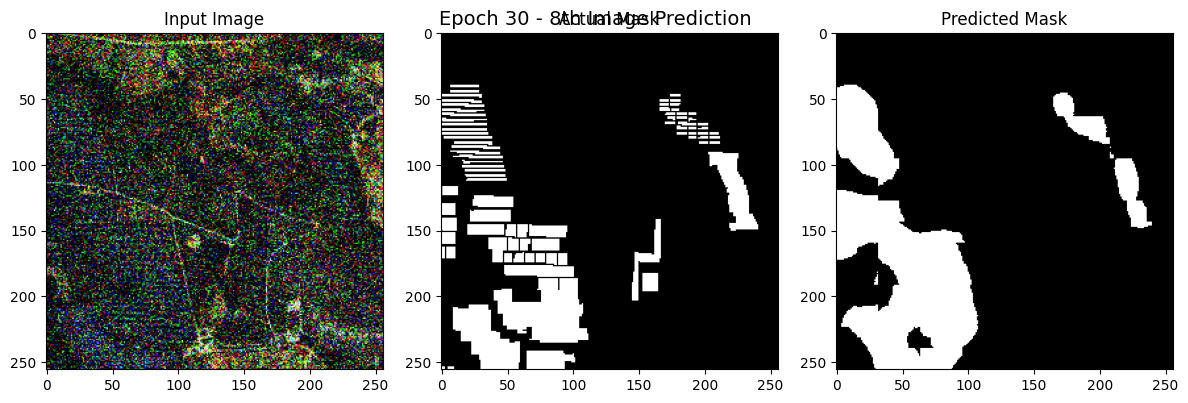

Epoch [30/200] | Train Loss: 0.1853 | Val Loss: 0.1865 | Dice: 0.8315 | IoU: 0.7209 | Acc: 0.9651


Epoch [31/200] | Train Loss: 0.1758 | Val Loss: 0.1699 | Dice: 0.8503 | IoU: 0.7469 | Acc: 0.9653


Epoch [32/200] | Train Loss: 0.1770 | Val Loss: 0.1732 | Dice: 0.8438 | IoU: 0.7368 | Acc: 0.9647


Epoch [33/200] | Train Loss: 0.1766 | Val Loss: 0.1587 | Dice: 0.8403 | IoU: 0.7363 | Acc: 0.9658


Epoch [34/200] | Train Loss: 0.1718 | Val Loss: 0.1756 | Dice: 0.8387 | IoU: 0.7294 | Acc: 0.9646


Epoch [35/200] | Train Loss: 0.1692 | Val Loss: 0.1624 | Dice: 0.8429 | IoU: 0.7391 | Acc: 0.9672


Epoch [36/200] | Train Loss: 0.1740 | Val Loss: 0.1756 | Dice: 0.8353 | IoU: 0.7261 | Acc: 0.9648


Epoch [37/200] | Train Loss: 0.1640 | Val Loss: 0.1533 | Dice: 0.8603 | IoU: 0.7602 | Acc: 0.9694


Epoch [38/200] | Train Loss: 0.1705 | Val Loss: 0.1601 | Dice: 0.8477 | IoU: 0.7421 | Acc: 0.9677


Epoch [39/200] | Train Loss: 0.1630 | Val Loss: 0.1663 | Dice: 0.8341 | IoU: 0.7312 | Acc: 0.9650


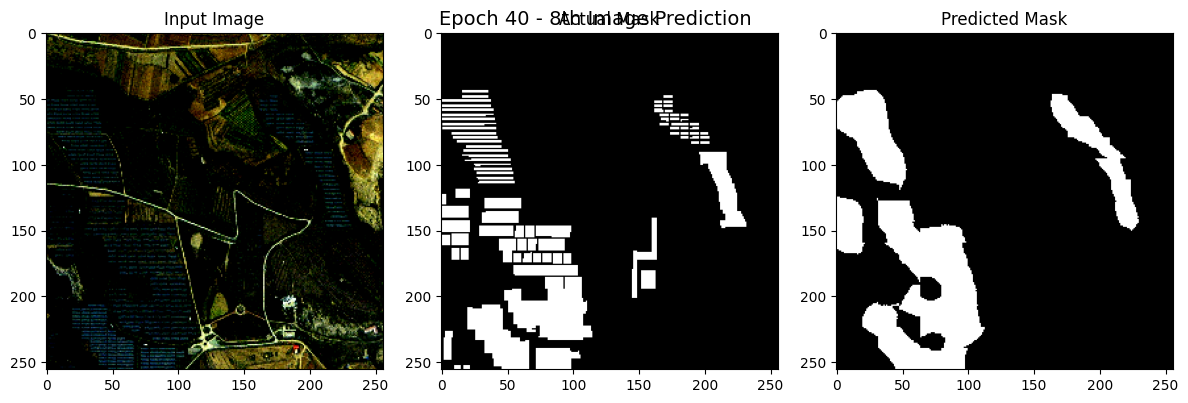

Epoch [40/200] | Train Loss: 0.1749 | Val Loss: 0.1532 | Dice: 0.8572 | IoU: 0.7566 | Acc: 0.9694


Epoch [41/200] | Train Loss: 0.1526 | Val Loss: 0.1513 | Dice: 0.8669 | IoU: 0.7714 | Acc: 0.9700


Epoch [42/200] | Train Loss: 0.1530 | Val Loss: 0.1541 | Dice: 0.8562 | IoU: 0.7585 | Acc: 0.9692


Epoch [43/200] | Train Loss: 0.1574 | Val Loss: 0.1677 | Dice: 0.8510 | IoU: 0.7479 | Acc: 0.9685


Epoch [44/200] | Train Loss: 0.1639 | Val Loss: 0.1449 | Dice: 0.8659 | IoU: 0.7699 | Acc: 0.9713


Epoch [45/200] | Train Loss: 0.1529 | Val Loss: 0.1569 | Dice: 0.8503 | IoU: 0.7480 | Acc: 0.9672


Epoch [46/200] | Train Loss: 0.1580 | Val Loss: 0.1501 | Dice: 0.8598 | IoU: 0.7630 | Acc: 0.9702


Epoch [47/200] | Train Loss: 0.1582 | Val Loss: 0.1580 | Dice: 0.8511 | IoU: 0.7502 | Acc: 0.9688


Epoch [48/200] | Train Loss: 0.1549 | Val Loss: 0.1603 | Dice: 0.8621 | IoU: 0.7659 | Acc: 0.9700


Epoch [49/200] | Train Loss: 0.1533 | Val Loss: 0.1563 | Dice: 0.8607 | IoU: 0.7613 | Acc: 0.9695


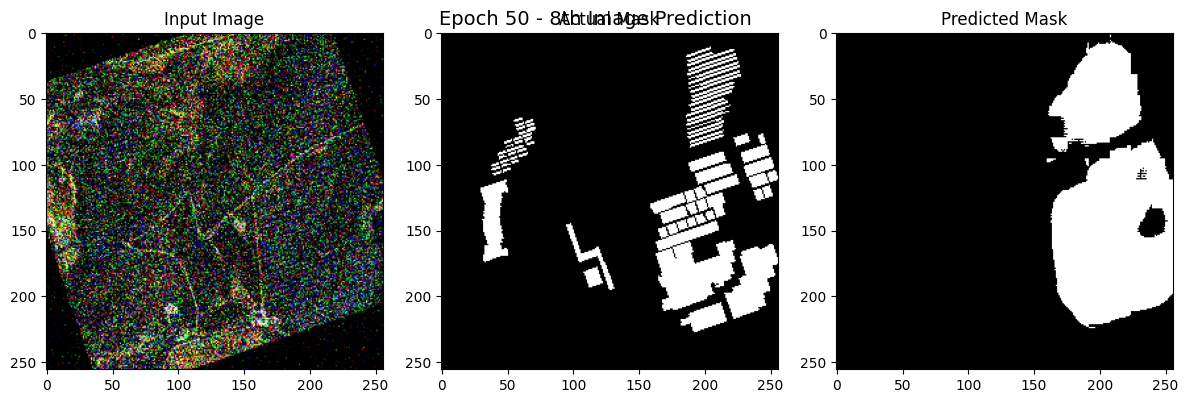

Epoch [50/200] | Train Loss: 0.1679 | Val Loss: 0.1808 | Dice: 0.8504 | IoU: 0.7491 | Acc: 0.9674


Epoch [51/200] | Train Loss: 0.1831 | Val Loss: 0.1692 | Dice: 0.8447 | IoU: 0.7407 | Acc: 0.9659


Epoch [52/200] | Train Loss: 0.1624 | Val Loss: 0.1647 | Dice: 0.8539 | IoU: 0.7524 | Acc: 0.9681


Epoch [53/200] | Train Loss: 0.1552 | Val Loss: 0.1529 | Dice: 0.8511 | IoU: 0.7479 | Acc: 0.9657


Epoch [54/200] | Train Loss: 0.1572 | Val Loss: 0.1476 | Dice: 0.8600 | IoU: 0.7619 | Acc: 0.9698


Epoch [55/200] | Train Loss: 0.1440 | Val Loss: 0.1462 | Dice: 0.8501 | IoU: 0.7502 | Acc: 0.9689


Epoch [56/200] | Train Loss: 0.1779 | Val Loss: 0.1582 | Dice: 0.8524 | IoU: 0.7523 | Acc: 0.9681


Epoch [57/200] | Train Loss: 0.1532 | Val Loss: 0.1492 | Dice: 0.8650 | IoU: 0.7712 | Acc: 0.9709


Epoch [58/200] | Train Loss: 0.1842 | Val Loss: 0.1686 | Dice: 0.8499 | IoU: 0.7489 | Acc: 0.9689


Epoch [59/200] | Train Loss: 0.1606 | Val Loss: 0.1696 | Dice: 0.8543 | IoU: 0.7533 | Acc: 0.9683


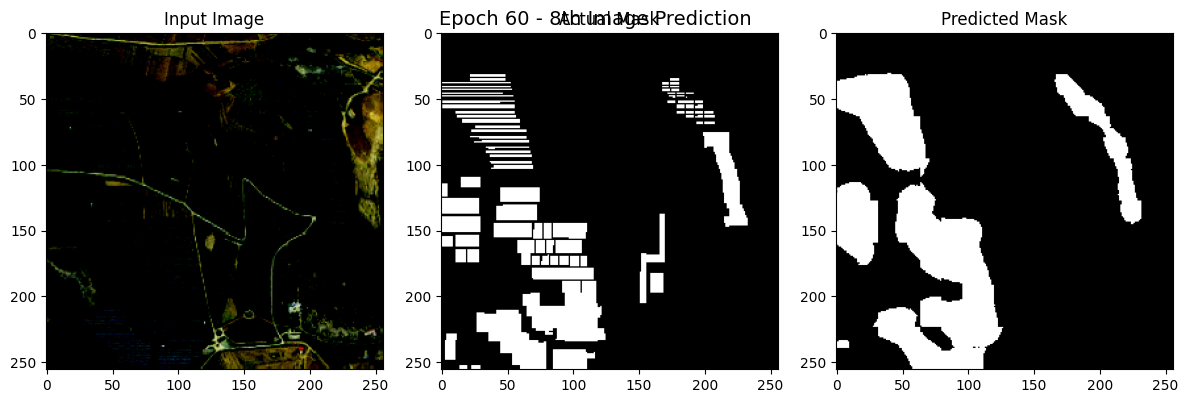

Epoch [60/200] | Train Loss: 0.1655 | Val Loss: 0.1636 | Dice: 0.8533 | IoU: 0.7542 | Acc: 0.9682


Epoch [61/200] | Train Loss: 0.1617 | Val Loss: 0.1606 | Dice: 0.8578 | IoU: 0.7593 | Acc: 0.9692


Epoch [62/200] | Train Loss: 0.1616 | Val Loss: 0.1489 | Dice: 0.8595 | IoU: 0.7612 | Acc: 0.9700


Epoch [63/200] | Train Loss: 0.1452 | Val Loss: 0.1459 | Dice: 0.8677 | IoU: 0.7739 | Acc: 0.9717


Epoch [64/200] | Train Loss: 0.1522 | Val Loss: 0.1684 | Dice: 0.8442 | IoU: 0.7393 | Acc: 0.9653


Epoch [65/200] | Train Loss: 0.1488 | Val Loss: 0.1456 | Dice: 0.8612 | IoU: 0.7631 | Acc: 0.9696


Epoch [66/200] | Train Loss: 0.1437 | Val Loss: 0.1429 | Dice: 0.8716 | IoU: 0.7811 | Acc: 0.9731


Epoch [67/200] | Train Loss: 0.1557 | Val Loss: 0.1348 | Dice: 0.8754 | IoU: 0.7860 | Acc: 0.9733


Epoch [68/200] | Train Loss: 0.1343 | Val Loss: 0.1568 | Dice: 0.8608 | IoU: 0.7657 | Acc: 0.9715


Epoch [69/200] | Train Loss: 0.1405 | Val Loss: 0.1427 | Dice: 0.8650 | IoU: 0.7685 | Acc: 0.9709


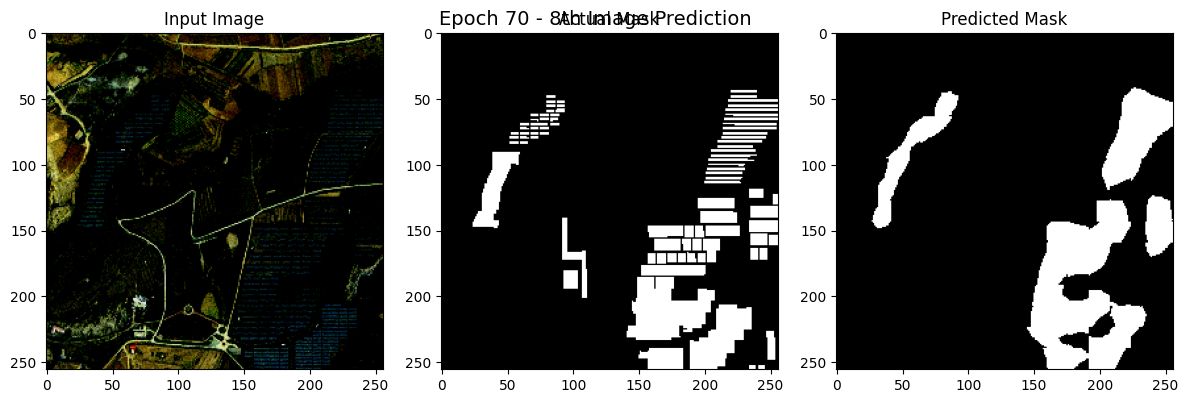

Epoch [70/200] | Train Loss: 0.1432 | Val Loss: 0.1429 | Dice: 0.8603 | IoU: 0.7632 | Acc: 0.9707


Epoch [71/200] | Train Loss: 0.1427 | Val Loss: 0.1367 | Dice: 0.8685 | IoU: 0.7736 | Acc: 0.9705


Epoch [72/200] | Train Loss: 0.1432 | Val Loss: 0.1398 | Dice: 0.8737 | IoU: 0.7817 | Acc: 0.9724


Epoch [73/200] | Train Loss: 0.1446 | Val Loss: 0.1297 | Dice: 0.8806 | IoU: 0.7929 | Acc: 0.9737


Epoch [74/200] | Train Loss: 0.1425 | Val Loss: 0.1398 | Dice: 0.8770 | IoU: 0.7874 | Acc: 0.9731


Epoch [75/200] | Train Loss: 0.1419 | Val Loss: 0.1332 | Dice: 0.8694 | IoU: 0.7762 | Acc: 0.9717


Epoch [76/200] | Train Loss: 0.1424 | Val Loss: 0.1404 | Dice: 0.8655 | IoU: 0.7730 | Acc: 0.9723


Epoch [77/200] | Train Loss: 0.1385 | Val Loss: 0.1490 | Dice: 0.8570 | IoU: 0.7625 | Acc: 0.9707


Epoch [78/200] | Train Loss: 0.1593 | Val Loss: 0.1592 | Dice: 0.8464 | IoU: 0.7452 | Acc: 0.9686


Epoch [79/200] | Train Loss: 0.1705 | Val Loss: 0.1633 | Dice: 0.8477 | IoU: 0.7437 | Acc: 0.9670


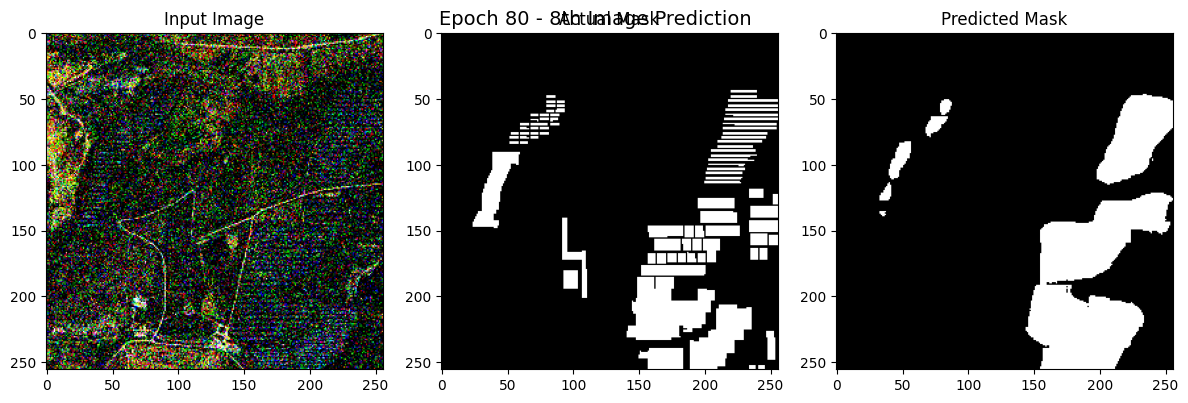

Epoch [80/200] | Train Loss: 0.1615 | Val Loss: 0.1569 | Dice: 0.8508 | IoU: 0.7479 | Acc: 0.9678


Epoch [81/200] | Train Loss: 0.1479 | Val Loss: 0.1378 | Dice: 0.8684 | IoU: 0.7753 | Acc: 0.9724


Epoch [82/200] | Train Loss: 0.1419 | Val Loss: 0.1381 | Dice: 0.8627 | IoU: 0.7642 | Acc: 0.9703


Epoch [83/200] | Train Loss: 0.1466 | Val Loss: 0.1367 | Dice: 0.8638 | IoU: 0.7675 | Acc: 0.9720


Epoch [84/200] | Train Loss: 0.1495 | Val Loss: 0.1463 | Dice: 0.8596 | IoU: 0.7598 | Acc: 0.9702


Epoch [85/200] | Train Loss: 0.1433 | Val Loss: 0.1343 | Dice: 0.8723 | IoU: 0.7803 | Acc: 0.9732


Epoch [86/200] | Train Loss: 0.1404 | Val Loss: 0.1508 | Dice: 0.8555 | IoU: 0.7571 | Acc: 0.9664


Epoch [87/200] | Train Loss: 0.1405 | Val Loss: 0.1623 | Dice: 0.8509 | IoU: 0.7505 | Acc: 0.9688


Epoch [88/200] | Train Loss: 0.1675 | Val Loss: 0.1766 | Dice: 0.8306 | IoU: 0.7220 | Acc: 0.9622


Epoch [89/200] | Train Loss: 0.1545 | Val Loss: 0.1611 | Dice: 0.8477 | IoU: 0.7455 | Acc: 0.9673


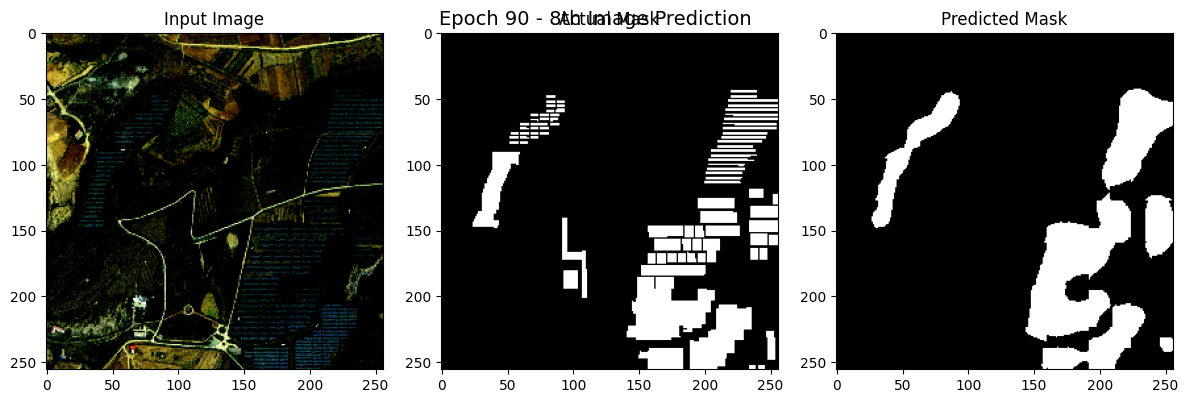

Epoch [90/200] | Train Loss: 0.1547 | Val Loss: 0.1471 | Dice: 0.8609 | IoU: 0.7658 | Acc: 0.9709


Epoch [91/200] | Train Loss: 0.1440 | Val Loss: 0.1407 | Dice: 0.8759 | IoU: 0.7877 | Acc: 0.9727


Epoch [92/200] | Train Loss: 0.1408 | Val Loss: 0.1440 | Dice: 0.8699 | IoU: 0.7768 | Acc: 0.9723


Epoch [93/200] | Train Loss: 0.1358 | Val Loss: 0.1460 | Dice: 0.8696 | IoU: 0.7767 | Acc: 0.9722


Epoch [94/200] | Train Loss: 0.1413 | Val Loss: 0.1243 | Dice: 0.8831 | IoU: 0.7974 | Acc: 0.9747


Epoch [95/200] | Train Loss: 0.1380 | Val Loss: 0.1426 | Dice: 0.8631 | IoU: 0.7703 | Acc: 0.9716


Epoch [96/200] | Train Loss: 0.1356 | Val Loss: 0.1384 | Dice: 0.8729 | IoU: 0.7809 | Acc: 0.9725


Epoch [97/200] | Train Loss: 0.1440 | Val Loss: 0.1379 | Dice: 0.8628 | IoU: 0.7678 | Acc: 0.9719


Epoch [98/200] | Train Loss: 0.1346 | Val Loss: 0.1363 | Dice: 0.8680 | IoU: 0.7762 | Acc: 0.9713


Epoch [99/200] | Train Loss: 0.1322 | Val Loss: 0.1492 | Dice: 0.8660 | IoU: 0.7687 | Acc: 0.9693


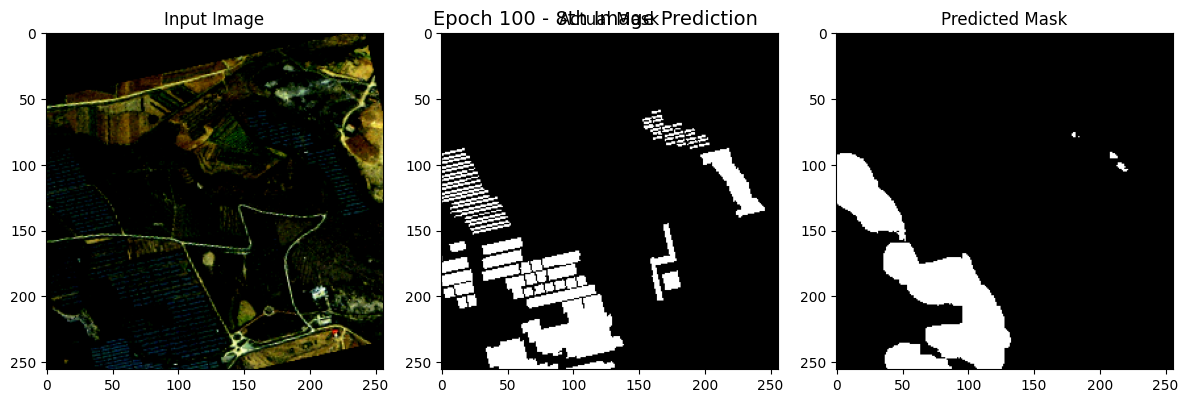

Epoch [100/200] | Train Loss: 0.1599 | Val Loss: 0.2024 | Dice: 0.8103 | IoU: 0.6921 | Acc: 0.9606


Epoch [101/200] | Train Loss: 0.1694 | Val Loss: 0.1398 | Dice: 0.8680 | IoU: 0.7743 | Acc: 0.9720


Epoch [102/200] | Train Loss: 0.1520 | Val Loss: 0.1606 | Dice: 0.8626 | IoU: 0.7656 | Acc: 0.9693


Epoch [103/200] | Train Loss: 0.1417 | Val Loss: 0.1413 | Dice: 0.8612 | IoU: 0.7651 | Acc: 0.9704


Epoch [104/200] | Train Loss: 0.1415 | Val Loss: 0.1430 | Dice: 0.8767 | IoU: 0.7864 | Acc: 0.9738


Epoch [105/200] | Train Loss: 0.1385 | Val Loss: 0.1320 | Dice: 0.8854 | IoU: 0.7996 | Acc: 0.9746


Epoch [106/200] | Train Loss: 0.1369 | Val Loss: 0.1304 | Dice: 0.8748 | IoU: 0.7863 | Acc: 0.9734


Epoch [107/200] | Train Loss: 0.1551 | Val Loss: 0.1715 | Dice: 0.8455 | IoU: 0.7395 | Acc: 0.9653


Epoch [108/200] | Train Loss: 0.1429 | Val Loss: 0.1439 | Dice: 0.8701 | IoU: 0.7766 | Acc: 0.9700


Epoch [109/200] | Train Loss: 0.1398 | Val Loss: 0.1413 | Dice: 0.8760 | IoU: 0.7867 | Acc: 0.9739


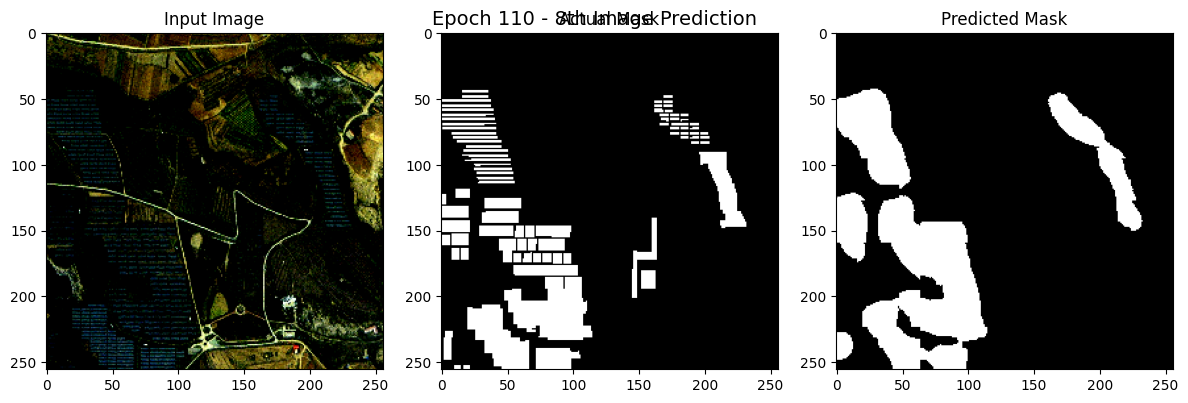

Epoch [110/200] | Train Loss: 0.1496 | Val Loss: 0.1356 | Dice: 0.8678 | IoU: 0.7747 | Acc: 0.9705


Epoch [111/200] | Train Loss: 0.1667 | Val Loss: 0.1492 | Dice: 0.8637 | IoU: 0.7681 | Acc: 0.9714


Epoch [112/200] | Train Loss: 0.1442 | Val Loss: 0.1403 | Dice: 0.8602 | IoU: 0.7619 | Acc: 0.9686


Epoch [113/200] | Train Loss: 0.1428 | Val Loss: 0.1225 | Dice: 0.8784 | IoU: 0.7893 | Acc: 0.9746


Epoch [114/200] | Train Loss: 0.1419 | Val Loss: 0.1334 | Dice: 0.8700 | IoU: 0.7775 | Acc: 0.9721


Epoch [115/200] | Train Loss: 0.1363 | Val Loss: 0.1444 | Dice: 0.8647 | IoU: 0.7729 | Acc: 0.9710


Epoch [116/200] | Train Loss: 0.1395 | Val Loss: 0.1340 | Dice: 0.8763 | IoU: 0.7881 | Acc: 0.9747


Epoch [117/200] | Train Loss: 0.1331 | Val Loss: 0.1348 | Dice: 0.8732 | IoU: 0.7838 | Acc: 0.9719


Epoch [118/200] | Train Loss: 0.1317 | Val Loss: 0.1314 | Dice: 0.8739 | IoU: 0.7864 | Acc: 0.9725


Epoch [119/200] | Train Loss: 0.1371 | Val Loss: 0.1371 | Dice: 0.8771 | IoU: 0.7876 | Acc: 0.9739


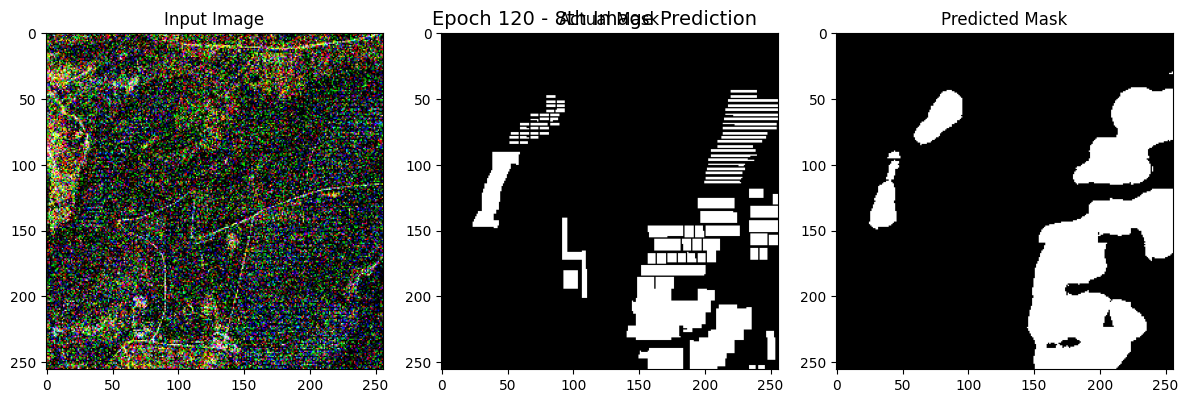

Epoch [120/200] | Train Loss: 0.1261 | Val Loss: 0.1281 | Dice: 0.8740 | IoU: 0.7828 | Acc: 0.9732


Epoch [121/200] | Train Loss: 0.1241 | Val Loss: 0.1292 | Dice: 0.8803 | IoU: 0.7929 | Acc: 0.9753


Epoch [122/200] | Train Loss: 0.1244 | Val Loss: 0.1272 | Dice: 0.8846 | IoU: 0.7999 | Acc: 0.9757


Epoch [123/200] | Train Loss: 0.1242 | Val Loss: 0.1412 | Dice: 0.8726 | IoU: 0.7805 | Acc: 0.9735


Epoch [124/200] | Train Loss: 0.1328 | Val Loss: 0.1350 | Dice: 0.8731 | IoU: 0.7827 | Acc: 0.9717


Epoch [125/200] | Train Loss: 0.1359 | Val Loss: 0.1295 | Dice: 0.8769 | IoU: 0.7903 | Acc: 0.9746


Epoch [126/200] | Train Loss: 0.1396 | Val Loss: 0.1426 | Dice: 0.8621 | IoU: 0.7649 | Acc: 0.9703


Epoch [127/200] | Train Loss: 0.1434 | Val Loss: 0.1556 | Dice: 0.8576 | IoU: 0.7581 | Acc: 0.9706


Epoch [128/200] | Train Loss: 0.1358 | Val Loss: 0.1441 | Dice: 0.8762 | IoU: 0.7869 | Acc: 0.9719


Epoch [129/200] | Train Loss: 0.1597 | Val Loss: 0.1621 | Dice: 0.8585 | IoU: 0.7595 | Acc: 0.9696


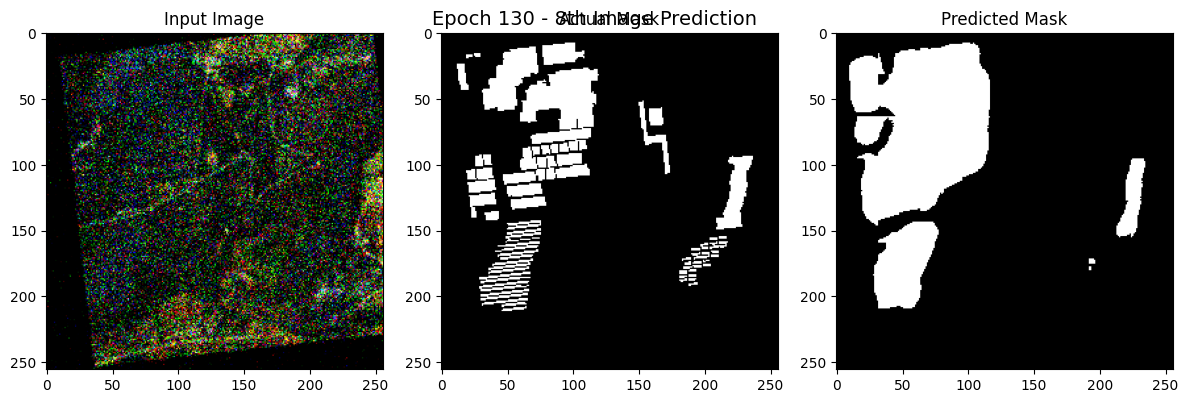

Epoch [130/200] | Train Loss: 0.1470 | Val Loss: 0.1417 | Dice: 0.8701 | IoU: 0.7767 | Acc: 0.9722


Epoch [131/200] | Train Loss: 0.1296 | Val Loss: 0.1335 | Dice: 0.8816 | IoU: 0.7967 | Acc: 0.9745


Epoch [132/200] | Train Loss: 0.1207 | Val Loss: 0.1235 | Dice: 0.8882 | IoU: 0.8043 | Acc: 0.9754


Epoch [133/200] | Train Loss: 0.1299 | Val Loss: 0.1309 | Dice: 0.8774 | IoU: 0.7884 | Acc: 0.9734


Epoch [134/200] | Train Loss: 0.1274 | Val Loss: 0.1304 | Dice: 0.8775 | IoU: 0.7892 | Acc: 0.9739


Epoch [135/200] | Train Loss: 0.1257 | Val Loss: 0.1333 | Dice: 0.8727 | IoU: 0.7805 | Acc: 0.9733


Epoch [136/200] | Train Loss: 0.1319 | Val Loss: 0.1339 | Dice: 0.8798 | IoU: 0.7935 | Acc: 0.9749


Epoch [137/200] | Train Loss: 0.1238 | Val Loss: 0.1405 | Dice: 0.8699 | IoU: 0.7763 | Acc: 0.9722


Epoch [138/200] | Train Loss: 0.1403 | Val Loss: 0.1356 | Dice: 0.8665 | IoU: 0.7720 | Acc: 0.9724


Epoch [139/200] | Train Loss: 0.1323 | Val Loss: 0.1373 | Dice: 0.8742 | IoU: 0.7833 | Acc: 0.9737


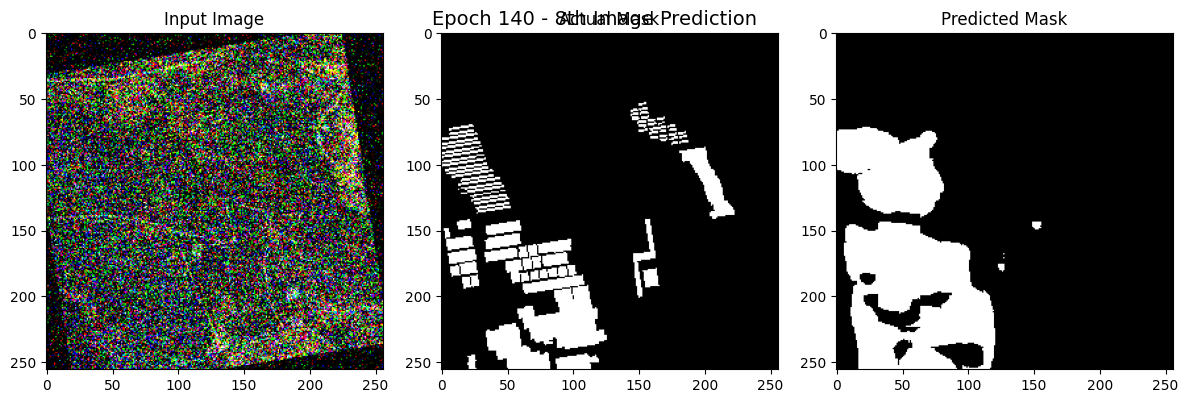

Epoch [140/200] | Train Loss: 0.1245 | Val Loss: 0.1347 | Dice: 0.8721 | IoU: 0.7834 | Acc: 0.9735


Epoch [141/200] | Train Loss: 0.1434 | Val Loss: 0.1361 | Dice: 0.8806 | IoU: 0.7937 | Acc: 0.9743


Epoch [142/200] | Train Loss: 0.1308 | Val Loss: 0.1282 | Dice: 0.8823 | IoU: 0.7954 | Acc: 0.9749


Epoch [143/200] | Train Loss: 0.1282 | Val Loss: 0.1381 | Dice: 0.8781 | IoU: 0.7884 | Acc: 0.9745


Epoch [144/200] | Train Loss: 0.1331 | Val Loss: 0.1278 | Dice: 0.8801 | IoU: 0.7922 | Acc: 0.9750


Epoch [145/200] | Train Loss: 0.1331 | Val Loss: 0.1282 | Dice: 0.8852 | IoU: 0.7991 | Acc: 0.9751


Epoch [146/200] | Train Loss: 0.1237 | Val Loss: 0.1319 | Dice: 0.8722 | IoU: 0.7812 | Acc: 0.9730


Epoch [147/200] | Train Loss: 0.1218 | Val Loss: 0.1375 | Dice: 0.8680 | IoU: 0.7778 | Acc: 0.9734


Epoch [148/200] | Train Loss: 0.1370 | Val Loss: 0.1658 | Dice: 0.8576 | IoU: 0.7664 | Acc: 0.9710


Epoch [149/200] | Train Loss: 0.1300 | Val Loss: 0.1303 | Dice: 0.8742 | IoU: 0.7897 | Acc: 0.9732


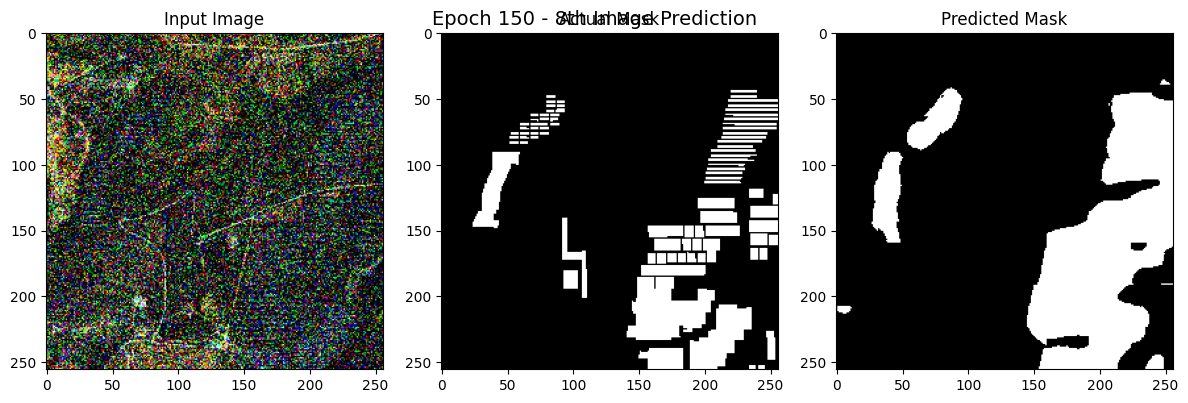

Epoch [150/200] | Train Loss: 0.1253 | Val Loss: 0.1284 | Dice: 0.8795 | IoU: 0.7913 | Acc: 0.9741


Epoch [151/200] | Train Loss: 0.1252 | Val Loss: 0.1286 | Dice: 0.8753 | IoU: 0.7860 | Acc: 0.9733


Epoch [152/200] | Train Loss: 0.1259 | Val Loss: 0.1206 | Dice: 0.8881 | IoU: 0.8035 | Acc: 0.9756


Epoch [153/200] | Train Loss: 0.1253 | Val Loss: 0.1299 | Dice: 0.8827 | IoU: 0.7978 | Acc: 0.9761


Epoch [154/200] | Train Loss: 0.1287 | Val Loss: 0.1149 | Dice: 0.8906 | IoU: 0.8083 | Acc: 0.9773


Epoch [155/200] | Train Loss: 0.1194 | Val Loss: 0.1199 | Dice: 0.8858 | IoU: 0.7994 | Acc: 0.9751


Epoch [156/200] | Train Loss: 0.1367 | Val Loss: 0.1301 | Dice: 0.8671 | IoU: 0.7764 | Acc: 0.9748


Epoch [157/200] | Train Loss: 0.1294 | Val Loss: 0.1260 | Dice: 0.8847 | IoU: 0.7978 | Acc: 0.9748


Epoch [158/200] | Train Loss: 0.1231 | Val Loss: 0.1233 | Dice: 0.8810 | IoU: 0.7956 | Acc: 0.9752


Epoch [159/200] | Train Loss: 0.1240 | Val Loss: 0.1359 | Dice: 0.8663 | IoU: 0.7739 | Acc: 0.9721


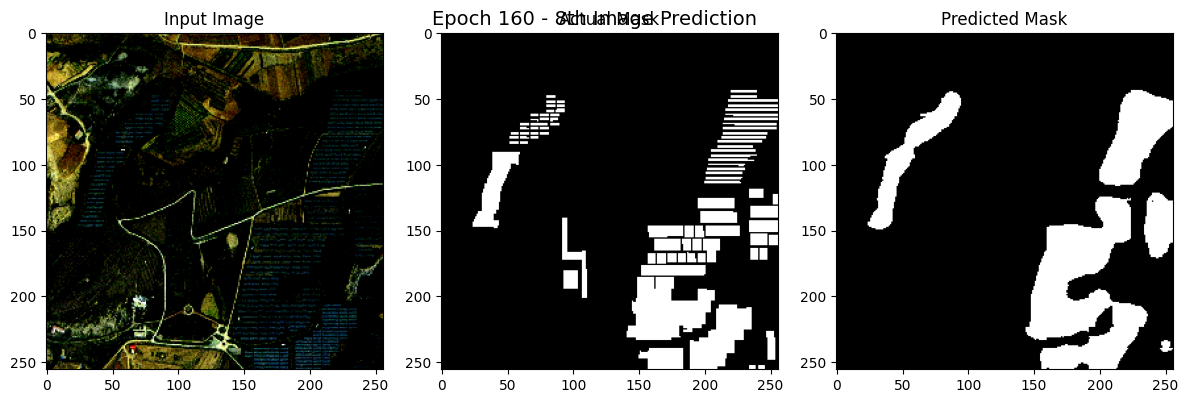

Epoch [160/200] | Train Loss: 0.1341 | Val Loss: 0.1399 | Dice: 0.8771 | IoU: 0.7878 | Acc: 0.9734


Epoch [161/200] | Train Loss: 0.1252 | Val Loss: 0.1511 | Dice: 0.8505 | IoU: 0.7546 | Acc: 0.9675


Epoch [162/200] | Train Loss: 0.1251 | Val Loss: 0.1295 | Dice: 0.8801 | IoU: 0.7914 | Acc: 0.9750


Epoch [163/200] | Train Loss: 0.1348 | Val Loss: 0.1265 | Dice: 0.8829 | IoU: 0.7977 | Acc: 0.9756


Epoch [164/200] | Train Loss: 0.1295 | Val Loss: 0.1226 | Dice: 0.8847 | IoU: 0.7975 | Acc: 0.9754


Epoch [165/200] | Train Loss: 0.1188 | Val Loss: 0.1304 | Dice: 0.8829 | IoU: 0.7965 | Acc: 0.9756


Epoch [166/200] | Train Loss: 0.1345 | Val Loss: 0.1481 | Dice: 0.8596 | IoU: 0.7636 | Acc: 0.9706


Epoch [167/200] | Train Loss: 0.1303 | Val Loss: 0.1270 | Dice: 0.8806 | IoU: 0.7939 | Acc: 0.9745


Epoch [168/200] | Train Loss: 0.1197 | Val Loss: 0.1355 | Dice: 0.8744 | IoU: 0.7876 | Acc: 0.9740


Epoch [169/200] | Train Loss: 0.1188 | Val Loss: 0.1581 | Dice: 0.8501 | IoU: 0.7516 | Acc: 0.9647


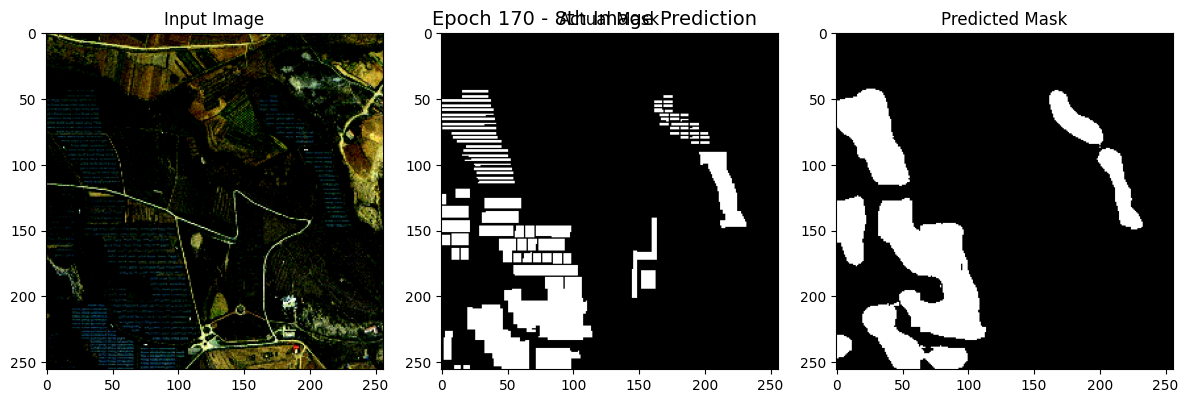

Epoch [170/200] | Train Loss: 0.1552 | Val Loss: 0.1215 | Dice: 0.8777 | IoU: 0.7912 | Acc: 0.9743


Epoch [171/200] | Train Loss: 0.1300 | Val Loss: 0.1365 | Dice: 0.8746 | IoU: 0.7847 | Acc: 0.9712


Epoch [172/200] | Train Loss: 0.1301 | Val Loss: 0.1437 | Dice: 0.8712 | IoU: 0.7772 | Acc: 0.9726


Epoch [173/200] | Train Loss: 0.1307 | Val Loss: 0.1350 | Dice: 0.8710 | IoU: 0.7790 | Acc: 0.9712


Epoch [174/200] | Train Loss: 0.1183 | Val Loss: 0.1136 | Dice: 0.8849 | IoU: 0.8005 | Acc: 0.9753


Epoch [175/200] | Train Loss: 0.1267 | Val Loss: 0.1316 | Dice: 0.8788 | IoU: 0.7923 | Acc: 0.9757


Epoch [176/200] | Train Loss: 0.1230 | Val Loss: 0.1314 | Dice: 0.8864 | IoU: 0.8006 | Acc: 0.9749


Epoch [177/200] | Train Loss: 0.1196 | Val Loss: 0.1297 | Dice: 0.8878 | IoU: 0.8034 | Acc: 0.9760


Epoch [178/200] | Train Loss: 0.1246 | Val Loss: 0.1322 | Dice: 0.8798 | IoU: 0.7933 | Acc: 0.9744


Epoch [179/200] | Train Loss: 0.1377 | Val Loss: 0.1227 | Dice: 0.8810 | IoU: 0.7955 | Acc: 0.9750


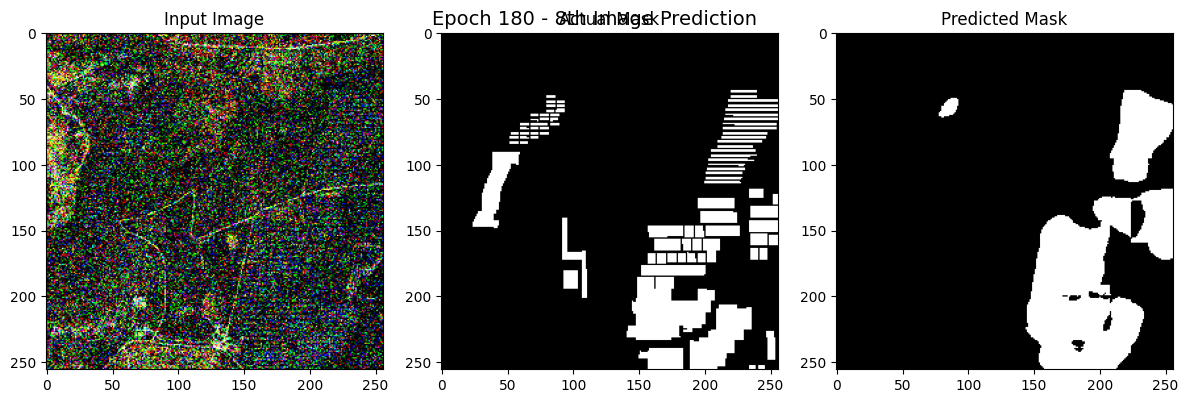

Epoch [180/200] | Train Loss: 0.1283 | Val Loss: 0.1255 | Dice: 0.8894 | IoU: 0.8072 | Acc: 0.9769


Epoch [181/200] | Train Loss: 0.1447 | Val Loss: 0.1263 | Dice: 0.8803 | IoU: 0.7932 | Acc: 0.9745


Epoch [182/200] | Train Loss: 0.1278 | Val Loss: 0.1212 | Dice: 0.8888 | IoU: 0.8057 | Acc: 0.9770


Epoch [183/200] | Train Loss: 0.1182 | Val Loss: 0.1148 | Dice: 0.8916 | IoU: 0.8100 | Acc: 0.9775


Epoch [184/200] | Train Loss: 0.1225 | Val Loss: 0.1208 | Dice: 0.8897 | IoU: 0.8075 | Acc: 0.9772


Epoch [185/200] | Train Loss: 0.1212 | Val Loss: 0.1346 | Dice: 0.8841 | IoU: 0.8018 | Acc: 0.9762


Epoch [186/200] | Train Loss: 0.1142 | Val Loss: 0.1209 | Dice: 0.8889 | IoU: 0.8051 | Acc: 0.9757


Epoch [187/200] | Train Loss: 0.1287 | Val Loss: 0.1412 | Dice: 0.8714 | IoU: 0.7818 | Acc: 0.9714


Epoch [188/200] | Train Loss: 0.1242 | Val Loss: 0.1301 | Dice: 0.8791 | IoU: 0.7906 | Acc: 0.9736


Epoch [189/200] | Train Loss: 0.1219 | Val Loss: 0.1312 | Dice: 0.8818 | IoU: 0.7945 | Acc: 0.9747


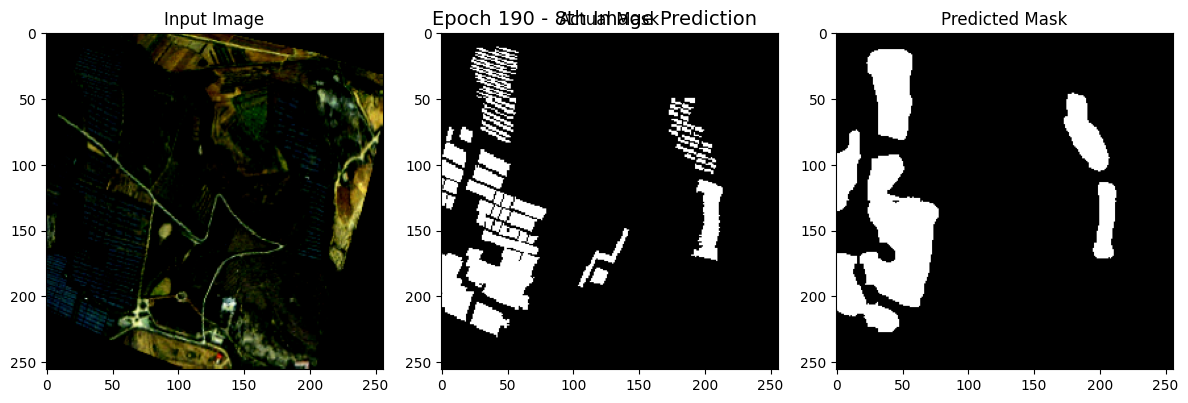

Epoch [190/200] | Train Loss: 0.1312 | Val Loss: 0.1329 | Dice: 0.8783 | IoU: 0.7890 | Acc: 0.9735


Epoch [191/200] | Train Loss: 0.1302 | Val Loss: 0.1260 | Dice: 0.8860 | IoU: 0.8022 | Acc: 0.9760


Epoch [192/200] | Train Loss: 0.1236 | Val Loss: 0.1263 | Dice: 0.8886 | IoU: 0.8054 | Acc: 0.9763


Epoch [193/200] | Train Loss: 0.1261 | Val Loss: 0.1338 | Dice: 0.8722 | IoU: 0.7811 | Acc: 0.9730


Epoch [194/200] | Train Loss: 0.1369 | Val Loss: 0.1284 | Dice: 0.8871 | IoU: 0.8047 | Acc: 0.9757


Epoch [195/200] | Train Loss: 0.1519 | Val Loss: 0.1481 | Dice: 0.8677 | IoU: 0.7734 | Acc: 0.9693


Epoch [196/200] | Train Loss: 0.1264 | Val Loss: 0.1354 | Dice: 0.8696 | IoU: 0.7846 | Acc: 0.9744


Epoch [197/200] | Train Loss: 0.1304 | Val Loss: 0.1497 | Dice: 0.8500 | IoU: 0.7509 | Acc: 0.9656


Epoch [198/200] | Train Loss: 0.1368 | Val Loss: 0.1287 | Dice: 0.8832 | IoU: 0.7957 | Acc: 0.9736


Epoch [199/200] | Train Loss: 0.1289 | Val Loss: 0.1324 | Dice: 0.8891 | IoU: 0.8044 | Acc: 0.9756


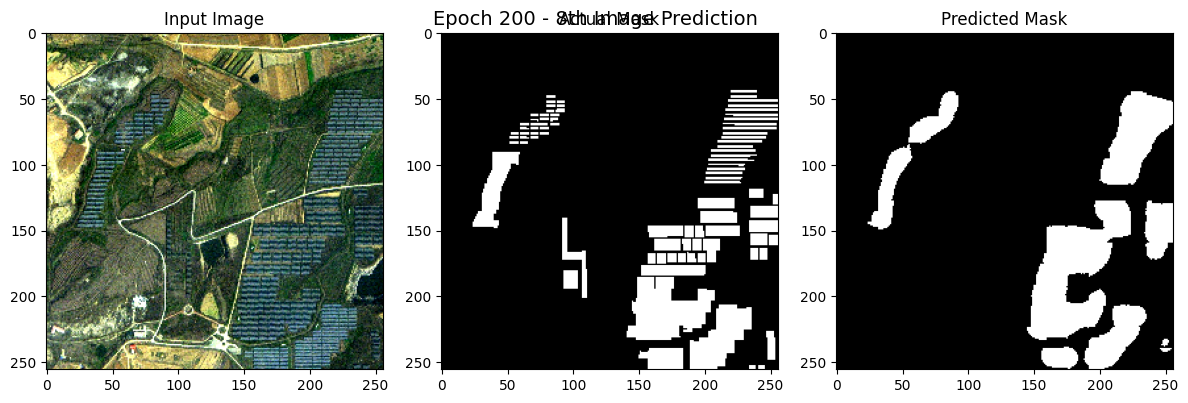

Epoch [200/200] | Train Loss: 0.1268 | Val Loss: 0.1433 | Dice: 0.8544 | IoU: 0.7549 | Acc: 0.9692
Training Complete!


In [ ]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

def visualize_single_mask(image, actual_mask, predicted_mask, epoch):
    """
    Visualizes only the 8th input image, its actual mask, and the predicted mask.
    """
    image = image.cpu().numpy()
    actual_mask = actual_mask.cpu().numpy()
    predicted_mask = (predicted_mask.sigmoid().cpu().numpy() > 0.5).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image.transpose(1, 2, 0))  # Convert CHW -> HWC
    axes[0].set_title("Input Image")

    axes[1].imshow(actual_mask.squeeze(), cmap="gray")  # Ensure 2D
    axes[1].set_title("Actual Mask")

    axes[2].imshow(predicted_mask.squeeze(), cmap="gray")  # Ensure 2D
    axes[2].set_title("Predicted Mask")

    plt.tight_layout()
    plt.suptitle(f"Epoch {epoch} - 8th Image Prediction", fontsize=14)
    plt.show()



# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegFormerUNet().to(device)
scaler = GradScaler()  # Enable Mixed Precision

def train_model(model, train_loader, val_loader, optimizer, num_epochs=10, device="cuda"):
    model.to(device)
    train_losses, val_losses = [], []
    dice_scores, iou_scores, acc_scores = [], [], []

    scaler = GradScaler()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for images, masks in train_loader_tqdm:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()

            with autocast():
                outputs = model(images)
                loss = DiceBCELoss()(outputs.float(), masks.float())

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_loss, total_dice, total_iou, total_acc = 0.0, 0.0, 0.0, 0.0
        num_samples = 0

        last_images, last_masks, last_outputs = None, None, None  # Store only the last batch

        with torch.no_grad():
            for batch_idx, (images, masks) in enumerate(val_loader):
                images, masks = images.to(device), masks.to(device)

                with autocast():
                    outputs = model(images)

                total_loss += DiceBCELoss()(outputs.float(), masks.float()).item()
                total_dice += dice_score(outputs, masks)
                total_iou += iou_score(outputs, masks)
                total_acc += pixel_accuracy(outputs.float(), masks.float())
                num_samples += 1

                # Store only the last batch
                last_images, last_masks, last_outputs = images, masks, outputs

        avg_val_loss = total_loss / num_samples
        avg_dice = total_dice / num_samples
        avg_iou = total_iou / num_samples
        avg_acc = total_acc / num_samples

        val_losses.append(avg_val_loss)
        dice_scores.append(avg_dice)
        iou_scores.append(avg_iou)
        acc_scores.append(avg_acc)
        if (epoch + 1) % 10== 0 and last_images is not None and last_images.shape[0] > 0:
          visualize_single_mask(last_images[0], last_masks[0], last_outputs[0], epoch + 1)

        avg_val_loss = total_loss / num_samples
        avg_dice = total_dice / num_samples
        avg_iou = total_iou / num_samples
        avg_acc = total_acc / num_samples

        val_losses.append(avg_val_loss)
        dice_scores.append(avg_dice)
        iou_scores.append(avg_iou)
        acc_scores.append(avg_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Dice: {avg_dice:.4f} | IoU: {avg_iou:.4f} | Acc: {avg_acc:.4f}")

    print("Training Complete!")
    return train_losses, val_losses, dice_scores, iou_scores, acc_scores

# Optimizer & Training
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
train_losses, val_losses, dice_scores, iou_scores, acc_scores = train_model(
    model, train_loader, val_loader, optimizer, num_epochs=200, device="cuda"
)

In [ ]:
val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

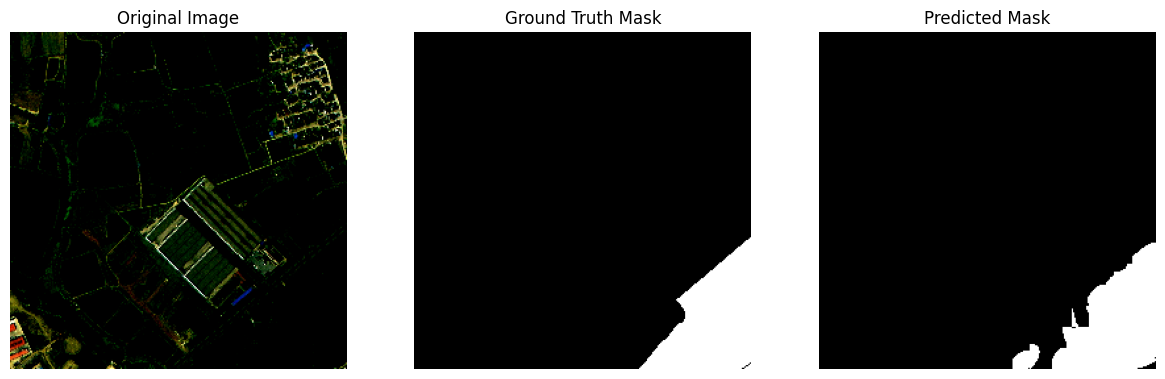

In [ ]:
def visualize_segformer_unet(val_dataset, model, idx=10):
    model.eval()

    # Load image and mask
    image, mask = val_dataset[idx]
    orig_image = np.moveaxis(image.numpy(), 0, -1)  # Convert (C, H, W) → (H, W, C)

    # Move image to GPU
    image = image.unsqueeze(0).cuda()

    with torch.no_grad():
        output = model(image)  # Retain input and get prediction

        pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()
        pred_mask = (pred_mask > 0.5).astype(np.uint8)  # Convert to binary mask

    # Convert ground truth mask to NumPy
    mask = mask.squeeze().cpu().numpy()

    # Plot all images
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(orig_image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

# Run visualization
visualize_segformer_unet(val_dataset, model, idx=5)

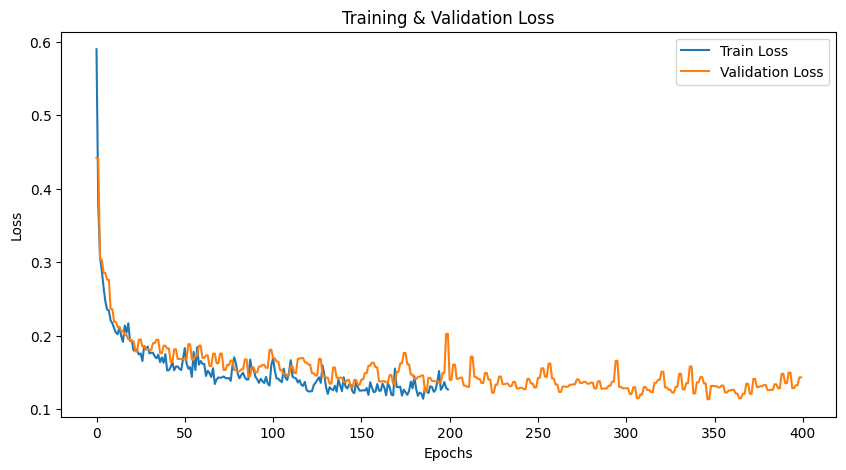

In [ ]:
# Plot Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

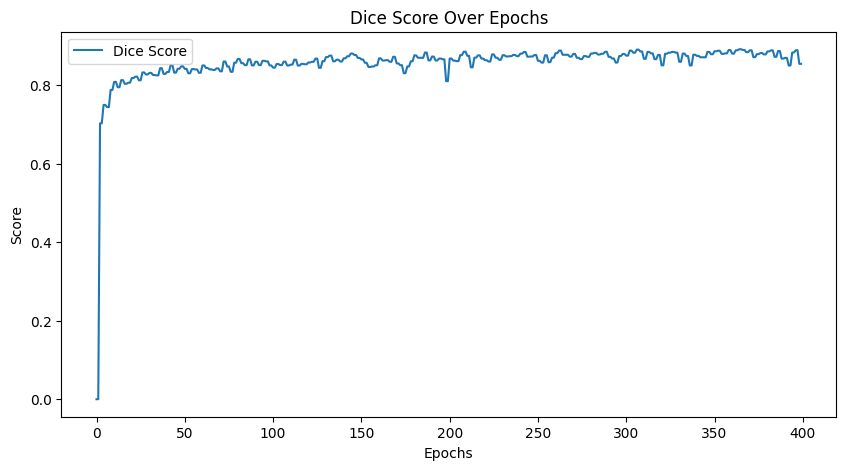

In [ ]:
# # Convert all tensors to CPU and NumPy
# dice_scores = [score.cpu().item() for score in dice_scores]  # .item() extracts scalar value

# # Plot Dice Scores
# plt.figure(figsize=(10, 5))
# plt.plot(dice_scores, label="Dice Score")
# plt.xlabel("Epochs")
# plt.ylabel("Score")
# plt.title("Dice Score Over Epochs")
# plt.legend()
# plt.show()

# Convert CUDA tensors to CPU scalars
dice_scores_cpu = [score.detach().cpu().item() for score in dice_scores]

plt.figure(figsize=(10, 5))
plt.plot(dice_scores_cpu, label="Dice Score")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("Dice Score Over Epochs")
plt.legend()
plt.show()

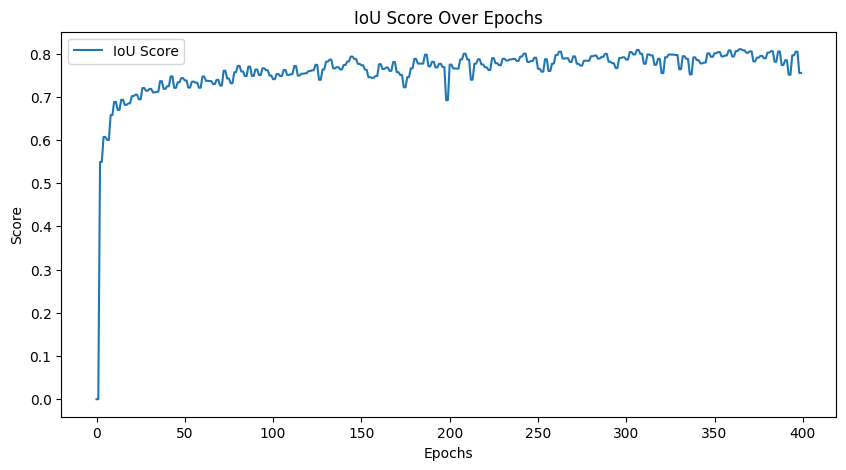

In [ ]:
# # Convert all tensors to CPU and extract values
# iou_scores = [score.cpu().item() for score in iou_scores]

# # Plot IoU Score
# plt.figure(figsize=(10, 5))
# plt.plot(iou_scores, label="IoU Score")
# plt.xlabel("Epochs")
# plt.ylabel("Score")
# plt.title("IoU Score Over Epochs")
# plt.legend()
# plt.show()




# If iou_scores is already a list of floats, use this:
iou_scores = [float(score) for score in iou_scores]  # Ensure it's a list of floats

# Plot IoU Score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(iou_scores, label="IoU Score")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("IoU Score Over Epochs")
plt.legend()
plt.show()

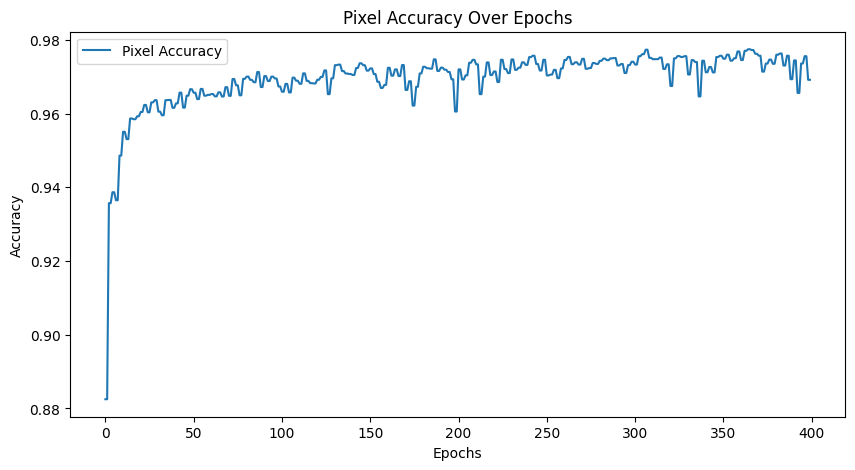

In [ ]:
# Plot Pixel Accuracy
plt.figure(figsize=(10, 5))
plt.plot(acc_scores, label="Pixel Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Pixel Accuracy Over Epochs")
plt.legend()
plt.show()

In [ ]:
# Save the trained model (recommended: save only state_dict)
torch.save(model.state_dict(), "segformer_unet_focal_loss_97_63.pth")

print(" Model saved successfully!")

 Model saved successfully!


# Packaging the Code

In [ ]:
def compute_solar_area(mask, PTM=0.125, OPTA=34):
    """
    Compute solar panel area from a binary segmentation mask.
    """
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().detach().numpy()  # Convert to NumPy if Tensor
    if mask.ndim == 3:
        mask = mask.squeeze(0)  # Remove extra channel

    mask = (mask > 0.5).astype(np.float32)  # Ensure binary mask
    panel_pixels = mask.sum()  # Count solar panel pixels
    area_m2 = (panel_pixels * (PTM ** 2)) / np.cos(np.radians(OPTA))  # Convert to m²
    return area_m2

def compute_accuracy_metrics(segmented_mask, actual_mask, PTM=0.125):
    """
    Compute accuracy of segmented area vs. actual area using MAPE and IoU.
    """
    # Compute solar panel areas
    segmented_area = compute_solar_area(segmented_mask, PTM)
    actual_area = compute_solar_area(actual_mask, PTM)

    # Compute Mean Absolute Percentage Error (MAPE)
    mape_error = np.abs((segmented_area - actual_area) / actual_area) * 100 if actual_area != 0 else 0

    # Compute Intersection over Union (IoU)
    intersection = ((segmented_mask > 0.5) & (actual_mask > 0.5)).sum()
    union = ((segmented_mask > 0.5) | (actual_mask > 0.5)).sum()
    iou_score = intersection / union if union != 0 else 0

    return {
        "Segmented Area (m²)": segmented_area,
        "Actual Area (m²)": actual_area,
        "MAPE (%)": mape_error,
        "IoU Score": iou_score
    }
def compute_energy_output(area_m2, efficiency=0.19, GTI=1676.2, PR=0.935):
    return area_m2 * efficiency * GTI * PR

### Segformer

In [ ]:
from transformers import SegformerForSemanticSegmentation
import torch

model = SegFormerUNet().cuda()
checkpoint_path = "/content/segformer_unet_focal_loss_97_63.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load model state dict
model.load_state_dict(checkpoint)

print("Model weights loaded successfully!")

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Model weights loaded successfully!


Number of different pixels: 639
--------------------
ORIGINAL MASK ENERGY OUTPUT
Estimated Solar Panel Area: 94.22 m²
Estimated Energy Output: 28.06 MWh per year
--------------------
--------------------
PREDICTED MASK ENERGY OUTPUT
Estimated Solar Panel Area: 101.62 m²
Estimated Energy Output: 30.26 MWh per year
--------------------


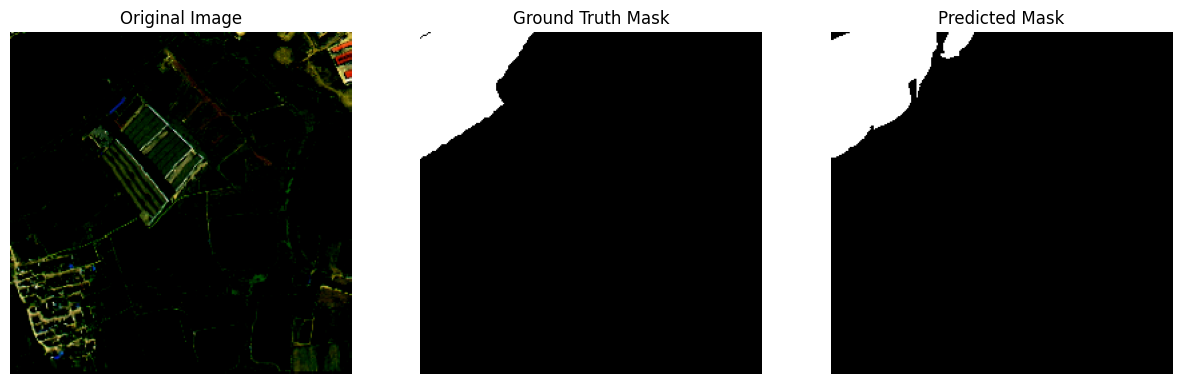

In [ ]:

def Calculate_solar_energy(val_dataset, model, idx=0):
    model.eval()

    # Load image and mask from validation set
    image, mask = val_dataset[idx]
    orig_image = np.moveaxis(image.numpy(), 0, -1)  # Convert from (C, H, W) to (H, W, C)

    # Move image to GPU
    image = image.unsqueeze(0).cuda()

    with torch.no_grad():
        output = model(image)  # Get raw logits
        pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()  # Convert logits to probabilities
        pred_mask = (pred_mask > 0.5).astype(np.uint8)  # Convert to binary mask

    # Resize ground truth mask for plotting
    mask = mask.squeeze().numpy()

    difference = np.sum(mask != pred_mask)
    print(f"Number of different pixels: {difference}")

    print("-"*20)
    # Compute area in m²
    area_m2 = compute_solar_area(mask)
    print("ORIGINAL MASK ENERGY OUTPUT")
    print(f"Estimated Solar Panel Area: {area_m2:.2f} m²")

    # Compute energy output in kWh
    energy_kwh = compute_energy_output(area_m2)
    print(f"Estimated Energy Output: {(energy_kwh/1000):.2f} MWh per year")
    print("-"*20)

    print("-"*20)
    # Compute area in m²
    area_m2 = compute_solar_area(pred_mask)
    print("PREDICTED MASK ENERGY OUTPUT")
    print(f"Estimated Solar Panel Area: {area_m2:.2f} m²")

    # Compute energy output in kWh
    energy_kwh = compute_energy_output(area_m2)
    print(f"Estimated Energy Output: {(energy_kwh/1000):.2f} MWh per year")
    print("-"*20)

    # Plot the results
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(orig_image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

# Run visualization for a random validation sample
Calculate_solar_energy(val_dataset, model, idx=5)

In [ ]:
import shutil
shutil.make_archive('/content/dataset/val_zip', 'zip', '/content/dataset/val')

'/content/dataset/val_zip.zip'